# Practical session 2 - Practise with classic libraries

Students (pair):
- [BOUILLY Marceau]()
- [SOULET Loïc]()

```
conda create --name=lab2 --file=requirement.txt
conda activate lab2
# do not forget to deactivate the environment if needed
# you can remove the environment once you are done
conda env remove --name=lab2
```

**Useful references for this lab**:

[1] `numpy`: [lecture notes (1.4.1-1.4.2)](https://scipy-lectures.org/intro/numpy/index.html) and [documentation](https://numpy.org/doc/stable/)

[2] `pandas`: [documentation](https://pandas.pydata.org/docs/getting_started/index.html), [quick tutorial](https://pandas.pydata.org/pandas-docs/version/0.15/10min.html)

[3] `matplotlib`: [lecture notes (1.5)](https://scipy-lectures.org/intro/matplotlib/index.html) and [documentation](https://matplotlib.org/)

[4] `h5py`: [quick start guide](http://docs.h5py.org/en/stable/quick.html#quick)

## <a name="content">Contents</a>
- [Exercise 1: Computing basic statistics](#ex1)
- [Exercise 2: Random variables and histograms](#ex2)
- [Exercise 3: Discrete isotropic total variation](#ex3)
---

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import unittest

---
## <a name="ex1">Exercise 1: Random variables and histograms</a>

In this exercise, we are interested in generating samples from the Gamma distribution $\mathcal{G}(\alpha,\beta)$, of probability density function (pdf)

\begin{equation}
    p(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} \exp(-\beta x) \mathbb{1}_{\mathbb{R}_+^*}(x),
\end{equation}

and displaying their histogram. In the following, we consider $(\alpha, \beta) = (9, 2)$.

1\. Set the random seed to a fixed value for reproducibility, and biefly check your instruction works as intended.
> Hint: you may take a look at the following pages: [random module](https://numpy.org/doc/stable/reference/random/index.html?highlight=random#module-numpy.random), [random generator](https://numpy.org/doc/stable/reference/random/generator.html).

In [ ]:
#We import the density functions we implemented in our complementary file
from ex_1_functions import p,p2

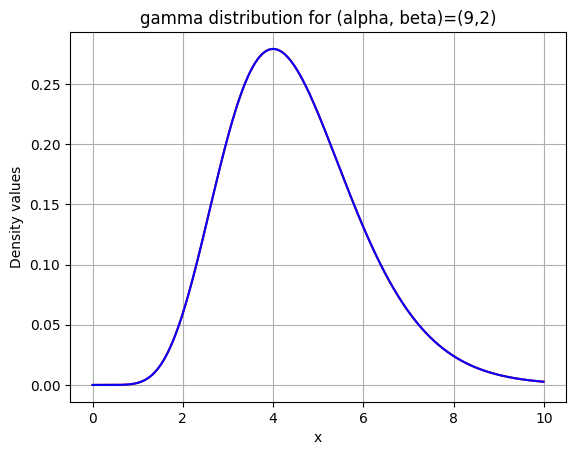

In [29]:
alpha,beta=9.0,2.0
n=1000
X=[0+i*10/n for i in range(n)]
f=[p(x,alpha,beta) for x in X]
g=[p2(x,alpha,beta) for x in X]
plt.plot(X,f, color="red")
plt.plot(X,g, color="blue")
plt.grid()
plt.xlabel("x")
plt.ylabel("Density values")
plt.title(label="gamma distribution for (alpha, beta)=(9,2)")
plt.show()


**Answer**:

In [5]:
# your code
#Fixed seed for reproducibility (same random patterns)
seed =42
rng =np.random.default_rng(seed)

In [6]:
#We use the gamme function of np.random, using the reverse scale as the beta parameter (different definition of gamma in the doc)
float1 = rng.gamma(alpha,1/beta)
rng =np.random.default_rng(seed)
float2 = rng.gamma(alpha,1/beta)

print(float1)
print(float2)

4.7975181262427125
4.7975181262427125


We can see that the random schema is the same

2\. Generate $\approx 10^5$ samples in a vector. Save the vector in a file, `samples.hdf5` or `samples.npy`.
> Warning / hint: 
> - take a careful look at the [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.gamma.html?highlight=gamma#numpy.random.gamma) (multiple conventions exist for the definition of the pdf underlying the distribution...);
> - to save data in a `npy` file, take a look at the example reported in the [Numpy documentation](https://numpy.org/doc/stable/reference/generated/numpy.save.html);
> - to save data in a `.h5` file, take a quick look at the [documentation here](https://docs.h5py.org/en/stable/quick.html#quick).

**Answer**:

In [7]:
# your code
samples = rng.gamma(alpha,1/beta,int(1e5))
print(f"samples: {samples}")
print(f"sample size: {len(samples)}")
with open("samples.npy","wb") as f:
    np.save(f, samples)

samples: [5.53448898 2.04919329 4.52424632 ... 6.646884   8.31019852 2.98093721]
sample size: 100000


3\. Estimate an histogram of this distribution for a well chosen set of bins, and display it.
> Warnings: 
> - make sure the [histogram](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist) corresponds to a probability density function (pdf);
> - do not forget to include a proper title with names for the axes.

**Answer**:

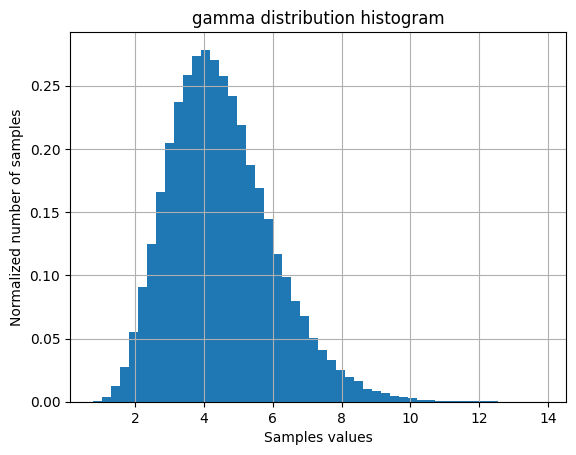

In [8]:
fig, ax = plt.subplots(1, 1)
ax.grid()
ax.hist(x=samples, density=True, bins=50)
#The bins are well chosen using the min and max values possible for the distribution, directly in the hist functions.
plt.xlabel("Samples values")
plt.ylabel("Normalized number of samples")
plt.title(label="gamma distribution histogram")
plt.show()

4\. Overlay the probability density function on the histogram and compare these in a few words. Save the resulting picture in `.png` format.
> Hint: 
> - take a look at the `scipy` [documentation](https://docs.scipy.org/doc/scipy/reference/stats.html) to avoid implementing the pdf from scratch;
> - return the bins in which the histogram is computed, and evaluate the pdf on those points.

**Answer**:

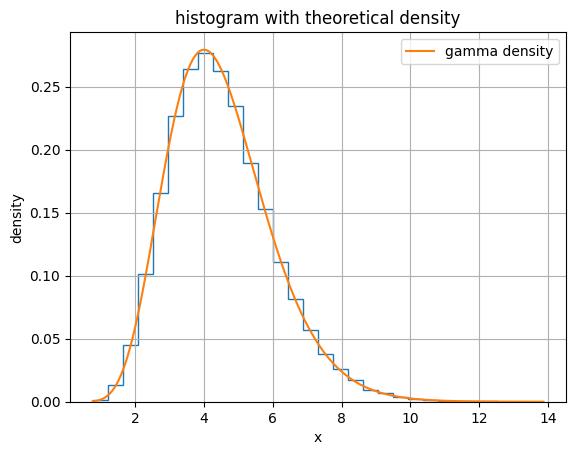

In [9]:
count, bins =np.histogram(samples, density=True, bins=30)
plt.stairs(count, bins)
X=np.linspace(bins[0],bins[-1],1000)
Y=np.array([p2(x,alpha,beta) for x in X])
plt.plot(X,Y,label="gamma density")
plt.xlabel('x')
plt.ylabel('density')
plt.title('histogram with theoretical density')
plt.legend()
plt.grid(True)
plt.savefig("density_vs_hist_random_samples_ex1.png")
plt.show()

**We can see on the graph above that the tendancy of the density is followed by the samples on the histogram. The fact that we used a large number of samples allows this result. With a lowest number, we could have seen more disparity**

---
## <a name="ex2">Exercise 2: Basic statistics with `pandas`</a>

In this second exercise, we focus on computing basic statistics, and applying linear regression to a small data set. These data are gathered in the following table, which gives the infant mortality (`X`) and the gross national product per inhabitant (`Y`) of 12 european countries :

| `X` | 190 | 128 | 180 | 212 | 56 | 192 | 68 | 98 | 110 | 197 | 181 | 233 |
|-----|-----|-----|-----|----|-----|----|----|-----|-----|-----|-----|-----|
| `Y` |  24 |  28 |  24 | 19 |  37 | 22 | 34 |  25 |  36 |  24 |  20 |  18 |

1\. For `X `and `Y`, compute the median, mean, variance and standard deviation. The data points have already been entered into a `.csv` file stored in `data/data.csv`.
> Hint: 
> - you can directly use `pandas` to load the data into a `DataFrame` ([`pd.read_csv`](https://pandas.pydata.org/docs/reference/frame.html));
> - take a look at the built-in operations available for `DataFrame` objects ([documentation](https://pandas.pydata.org/docs/reference/frame.html));
> - to display a `DataFrame` `f`:
> ```python 
> from IPython.display import display
> display(df)
> ```
> - sort the `DataFrame` with respect to the value of `X` (see [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values)) This will be useful for question 3.

We first test our complementary functions for this exercise. You can find them in ex_2_functions.py

In [10]:
!pytest -v test_ex_2_functions.py

============================= test session starts =============================
platform win32 -- Python 3.12.2, pytest-8.4.2, pluggy-1.6.0 -- c:\Users\loics\Documents\COURS_2025_2026\SDI\python_cours\TP1\python_sdia\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\loics\Documents\COURS_2025_2026\SDI\python_cours\TP1\python_sdia\Labs\Lab2
collecting ... collected 10 items

test_ex_2_functions.py::test_mean_basic PASSED                           [ 10%]
test_ex_2_functions.py::test_mean_single_value PASSED                    [ 20%]
test_ex_2_functions.py::test_mean_empty PASSED                           [ 30%]
test_ex_2_functions.py::test_variance_basic PASSED                       [ 40%]
test_ex_2_functions.py::test_variance_zero PASSED                        [ 50%]
test_ex_2_functions.py::test_variance_empty PASSED                       [ 60%]
test_ex_2_functions.py::test_variance_none_mean PASSED                   [ 70%]
test_ex_2_functions.py::test_line_basic PASSED

**Answer**:

In [11]:
# your code
dataframe= pd.read_csv("data/data.csv")
display(dataframe)

,X,Y
0,190,24
1,128,28
2,180,24
3,212,19
4,56,37
5,192,22
6,68,34
7,98,25
8,110,36
9,197,24


In [12]:
dataframe=dataframe.sort_values(by=["X"],ascending=True)
dataframe=dataframe.reset_index(drop=True)
dataframe

,X,Y
0,56,37
1,68,34
2,98,25
3,110,36
4,128,28
5,180,24
6,181,20
7,190,24
8,192,22
9,197,24


In [ ]:
#We import our complementary functions
from ex_2_functions import mean, variance

def stats(data, col):
    X=list(data[col])
    if (X==None):
        return None
    median = X[len(X)//2]
    mean_value=mean(X)
    var_value=variance(X,mean_value)
    return median, mean_value,var_value, np.sqrt(var_value)

def print_stats(statistics, col):
    print(f"{col} stats: median: {statistics[0]}, mean: {statistics[1]}, variance: {statistics[2]}, standard deviation: {statistics[-1]}")


In [14]:
stats_X=stats(dataframe,"X")
stats_Y=stats(dataframe,"Y")
print_stats(stats_X, "X")
print_stats(stats_Y, "Y")

X stats: median: 181, mean: 153.75, variance: 3195.5208333333335, standard deviation: 56.52893801703101
Y stats: median: 20, mean: 25.916666666666668, variance: 38.90972222222222, standard deviation: 6.237765803733114


2\. Give the equation of the regression line of `Y` as a function of `X`.
> Hint: 
> - take a look at the functionalities available in `numpy` (e.g., `np.polyfit` and `np.polyval`);
> - if needed, note that you can retrieve the data from the resulting `pandas` `DataFrame` with the `to_numpy()` method.

**Answer**:

In [15]:
# your code
#We get the data columns and convert it into numpy arrays
X=dataframe["X"].to_numpy()
Y=dataframe["Y"].to_numpy()
#We use np.polyfit, and as we look for a regression line, we select deg=1
f = np.polyfit(X,Y,deg=1)
print(f)

[-0.09816475 41.0094968 ]


In [16]:
#We now can get the regression coefficient as the result list is in the order of the higher power first
print(f"The regression line is given by: Y={f[0]}X + {f[-1]}")

The regression line is given by: Y=-0.0981647488346319X + 41.009496799991325


3\. Display the cloud of points and the regression line $Y = f(X)$ on the same figure. Save the figure in `.png` format.

**Answer**:

C:\Users\loics\AppData\Local\Temp\ipykernel_10192\352113963.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


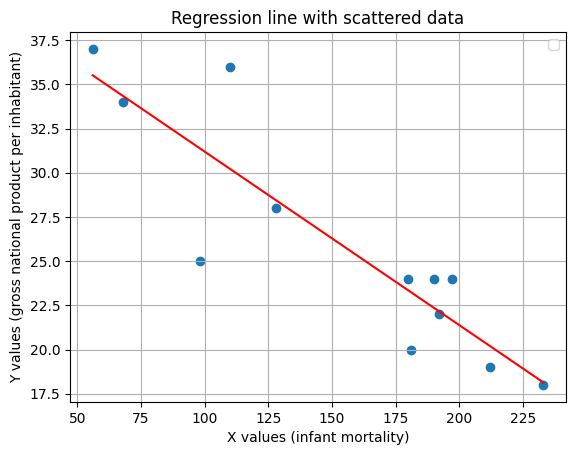

In [17]:
# your code
from ex_2_functions import line

#The dataframe is sorted
min_X=dataframe.loc[0,"X"]
max_X=dataframe.loc[dataframe.index[-1],"X"]
X = np.linspace(min_X,max_X, 1000)
Y= np.array([line(x,f) for x in X])
plt.scatter(dataframe["X"], dataframe["Y"])
plt.plot(X,Y,color="red")
plt.xlabel('X values (infant mortality)')
plt.ylabel('Y values (gross national product per inhabitant)')
plt.title('Regression line with scattered data')
plt.legend()
plt.grid(True)
plt.savefig("cloud_regression_ex2.png")
plt.show()

---
## <a name="ex3">Exercise 3: Discrete isotropic total variation</a>

This exercise is devoted to the computation of the discrete isotropic total variation (TV) of an input matrix $\mathbf{X} = [\mathbf{x}_n]_{1 \leq n \leq N} \in\mathbb{C}^{M \times N}$, which is particularly useful in Bayesian inference (e.g., for inverse problems) to promote piece-wise smooth solutions. The TV is defined as

\begin{equation*}
    \text{TV}(\mathbf{X}) = \Vert D(\mathbf{X}) \Vert_{1,2} = \sum_{m=1}^M \sum_{n=1}^N \sqrt{[\mathbf{XD}_h]^2_{m,n} + [\mathbf{D}_v\mathbf{X}]^2_{m,n}},
\end{equation*}

where $[\mathbf{Z}]_{m,n}$ denotes the elements in position $(m,n)$ of the matrix $\mathbf{Z}$,

\begin{align*}
    D(X) &= (\mathbf{XD}_h, \mathbf{D}_v\mathbf{X}) \in \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \\
    %
    \mathbf{XD}_h &= [\mathbf{x}_2-\mathbf{x}_1, \dotsc, \mathbf{x}_N-\mathbf{x}_{N-1}, \mathbf{0}_M] \in \mathbb{C}^{M\times N} \\
    %
    \mathbf{D}_v\mathbf{X} &= [\tilde{\mathbf{x}}_2^T-\tilde{\mathbf{x}}^T_1, \dotsc, \tilde{\mathbf{x}}^T_M-\tilde{\mathbf{x}}^T_{M-1}, \mathbf{0}_N]^T \in \mathbb{C}^{M\times N},
\end{align*}

$\mathbf{x}_n \in \mathbb{C}^{M}$ is the $n$-th column of $\mathbf{X}$, and $\tilde{\mathbf{x}}_m \in \mathbb{C}^{1\times N}$ is the $m$-th row of $\mathbf{X}$. 
The linear operator $D: \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} $ is the discrete gradient operator. The adjoint of $D$, $D^*: \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N}$, is given by

\begin{align*}
    (\forall \mathbf{Y} = (\mathbf{Y}_h,\mathbf{Y}_v)), \quad D^*(\mathbf{Y}) &= \mathbf{Y}_h\mathbf{D}^*_h + \mathbf{D}^*_v\mathbf{Y}_v \\
    %
    \mathbf{Y}_h\mathbf{D}^*_h &= \big[-\mathbf{y}_{h,1},- [\mathbf{y}_{h,n}-\mathbf{y}_{h,n-1}]_{2 \leq n \leq N-1}, \mathbf{y}_{h, N-1} \big] \\
    %
    \mathbf{D}^*_v\mathbf{Y}_v &= \big[-\tilde{\mathbf{y}}_{v,1}^T,- [\tilde{\mathbf{y}}_{v,m}^T-\tilde{\mathbf{y}}^T_{v,m-1}]_{2 \leq m \leq M-1}, \tilde{\mathbf{y}}^T_{v, M-1} \big]^T
\end{align*}

where $\mathbf{y}_{h,n}$ is the $n$-th column of $\mathbf{Y}_h$, and $\tilde{\mathbf{x}}_{v,m}$ is the $m$-th row of $\mathbf{Y}_v$.

1\. Using `numpy`, implement a function `gradient2D` to compute the 2D discrete gradient operator $D$ applied to a matrix $\mathbf{X}\in\mathbb{C}^{M \times N}$ (no for loops!). Trigger an error message whenever the input array has more than 2 dimensions. If not clear from the implementation, add a few short comments to explain your code.

> Hint: 
> - to trigger an error, you can for instance use an `assert` statement, or raise an [exception (e.g., `AssertionError`)](https://docs.python.org/3/library/exceptions.html);
> - only a few operations are needed: computing vertical differences, horizontal differences, and possibly a concatenation of matrices into a single tensor (= n-dimensional array);
> - possibly useful functions: `np.diff`, `np.c_`, `np.r_` (or `np.concatenate`). 

We first test our complementary functions for this exercise. You can find them in ex_3_functions.py

In [18]:
!pytest -v test_ex_3_functions.py

============================= test session starts =============================
platform win32 -- Python 3.12.2, pytest-8.4.2, pluggy-1.6.0 -- c:\Users\loics\Documents\COURS_2025_2026\SDI\python_cours\TP1\python_sdia\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\loics\Documents\COURS_2025_2026\SDI\python_cours\TP1\python_sdia\Labs\Lab2
collecting ... collected 4 items

test_ex_3_functions.py::test_XDh_basic PASSED                            [ 25%]
test_ex_3_functions.py::test_XDh_invalid_input PASSED                    [ 50%]
test_ex_3_functions.py::test_DvX_basic PASSED                            [ 75%]
test_ex_3_functions.py::test_DvX_invalid_input PASSED                    [100%]

============================== 4 passed in 0.65s ==============================


**Answer**:

In [19]:
from ex_3_functions import XDh,DvX
#The complementary functions used for thec calculations are in the module file
def gradient2D(X):
    """
    Computes the horizontal and vertical gradient of a 2D matrix.

    Args:
    X(np.ndarray): the input matrix

    Return:
    np.ndarray a 3D Volume containing the two gradient matrix, horizontal and vertical
    """
    if (X.ndim!=2):
        raise Exception("The input array as more than two dimensions")
    return np.stack([XDh(X),DvX(X)],axis=0)


In [ ]:
#Some try for DvX and XDh
#Unit tests can be found in the dedicated file
X=np.array([[1,2,3],[4,5,6],[7,8,9]])
print(f"X:{X}")
r1=XDh(X)
print(f"r1: {r1}")
r2=DvX(X)
print(f"r2: {r2}")

X:[[1 2 3]
 [4 5 6]
 [7 8 9]]
r1: [[1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]]
r2: [[3. 3. 3.]
 [3. 3. 3.]
 [0. 0. 0.]]


2\. Implement a unit-test to validate the behaviour of the `gradient2D` function. For instance, you can check the format of the output, and test the result when the function is evaluated on a constant matrix (for both a square and a non-square input matrix). Run the unit-test from the present Jupyter notebook.

**Answer**:

In [ ]:
# your code
#First matrix we use for the test
X=np.array([[1,2,3],[4,5,6],[7,8,9]])

#Second matrix we use for the test (volume)
Y1=np.array([[1,2,3],[4,5,6],[7,8,9]])
Y2=np.array([[1,2,3],[4,5,6],[7,8,9]])
Y = np.stack([Y1, Y2], axis=0)

#Third matrix for unit test
X_non_square=np.array([[1,2,3],[4,5,6]])

#Here we use unittest from the python library to have the possibility
#of running clean unit tests directly in the cell
class TestGradient2D(unittest.TestCase):
    def test_square_matrix_gradient_return(self):
        grad = gradient2D(X)
        self.assertEqual(grad.ndim,3)
        self.assertEqual(grad[0].ndim,2)
        self.assertEqual(grad[0].shape, (3,3))
        self.assertEqual(grad[1].ndim,2)
        self.assertEqual(grad[1].shape ,(3,3))

    def test_non_square_matrix_gradient_return(self):
        grad_non_square = gradient2D(X_non_square)
        self.assertEqual(grad_non_square.ndim,3)
        self.assertEqual(grad_non_square[0].ndim,2)
        self.assertEqual(grad_non_square[0].shape,(2,3))
        self.assertEqual(grad_non_square[1].ndim,2)
        self.assertEqual(grad_non_square[1].shape,(2,3))

    def test_volume_gradient_return(self):
        with self.assertRaises(Exception) as context:
            gradient2D(Y)
        self.assertIn("The input array as more than two dimensions", str(context.exception))

unittest.main(argv=[''], verbosity=2, exit=False)

test_non_square_matrix_gradient_return (__main__.TestGradient2D.test_non_square_matrix_gradient_return) ... ok
test_square_matrix_gradient_return (__main__.TestGradient2D.test_square_matrix_gradient_return) ... ok
test_volume_gradient_return (__main__.TestGradient2D.test_volume_gradient_return) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.004s

OK


3\. Document the function `gradient2D` with an appropriate docstring (see Lab 1).

**Answer**:

In [22]:
# your code
#You can see the docstring directly in the definition of the function above

4\. Using 1., define a function `tv` to compute $\text{TV}(\mathbf{X})$, $\mathbf{X}\in\mathbb{C}^{M \times N}$. Write a unit-test and document your function.

**Answer**:

In [23]:
# your code
def TV(X):
    """
    Computes the discrete isotropic total variation of a 2D matrix.

    Args:
    X(np.ndarray): the input matrix

    Return:
    float: the value of the total variation, calculated using the gradient2D function
    """
    gradient=gradient2D(X)
    norm1,norm2= np.abs(gradient[0])**2, np.abs(gradient[1])**2
    sum_matrix = norm1+norm2
    square=np.sqrt(sum_matrix)
    result =np.sum(square)
    return result

In [ ]:
class TestTV(unittest.TestCase):
    def test_tv_constant(self):
        #With a constant columns among the matrix, the TV is supposed to be zero
        X = np.zeros((3, 3))
        result=TV(X)
        np.testing.assert_allclose(result,0,atol=1e-6,rtol=1e-8)

    def test_tv_known(self):
      #We did the calculation by hand to know the result to expect
        X = np.array([[0, 0, 0],
                      [0, 1, 0],
                      [0, 0, 0]], dtype=float)
        result=TV(X)
        np.testing.assert_allclose(result,3.41,atol=1e-2)

unittest.main(argv=[''], verbosity=2, exit=False)

test_non_square_matrix_gradient_return (__main__.TestGradient2D.test_non_square_matrix_gradient_return) ... ok
test_square_matrix_gradient_return (__main__.TestGradient2D.test_square_matrix_gradient_return) ... ok
test_volume_gradient_return (__main__.TestGradient2D.test_volume_gradient_return) ... ok
test_tv_constant (__main__.TestTV.test_tv_constant) ... ok
test_tv_known (__main__.TestTV.test_tv_known) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.007s

OK


5\. Implement a function `gradient2D_adjoint` to compute $D^*(\mathbf{Y})$, the adjoint of the 2D discrete gradient operator $D$ applied to $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$. Add a few short comments to explain your code whenever appropriate.

**Answer**:

In [ ]:
# your code
#We import he complementary functions for the adjoint
from ex_3_functions import YDh, DvY
def gradient2D_adjoint(Y):
    """
    Computes the gradient adjoint gradient of a 3D matrix.

    Args:
    Y(np.ndarray): the input matrix, which is constitued of two matrixes of same size m,n

    Return:
    np.ndarray: a 2D matrix containing the resulting values of the gradient adjoint
    """
    assert Y.ndim==3
    return YDh(Y[0])+ DvY(Y[1])


6\. Implement a unit-test to validate `gradient2D_adjoint`, e.g., by checking the size of the output from the function and verifying that `gradient2D_adjoint` is adjoint to `gradient2D`, i.e., for any $\mathbf{X}\in\mathbb{C}^{M \times N}$ and $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$:

\begin{equation}
    \forall \mathbf{X} \in \mathbb{C}^{M \times N}, \mathbf{Y} = (\mathbf{Y}_h, \mathbf{Y}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \;
    %
    \langle D(\mathbf{X}), \mathbf{Y} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{X}, D^*(\mathbf{Y}) \rangle_{\mathbb{C}^{M \times N}}, 
\end{equation}

where 

\begin{align}
    &\forall \mathbf{U}, \mathbf{V} \in \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N}} = \text{Tr}(\mathbf{U}^T \mathbf{V}) = \sum_{m=1}^M \sum_{n=1}^N u_{m,n}^* v_{m,n}, \\
    &\forall \mathbf{U} = (\mathbf{U}_h, \mathbf{U}_v), \mathbf{V} = (\mathbf{V}_h, \mathbf{V}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{U}_h, \mathbf{V}_h \rangle_{\mathbb{C}^{M \times N}} + \langle \mathbf{U}_v, \mathbf{V}_v \rangle_{\mathbb{C}^{M \times N}}.
\end{align}

> Hint: to verify `gradient2D_adjoint` is the adjoint of `gradient2D`, evaluate the scalar products above for randomly drawn matrices. Set the random generator to a known state for reproducibility (see [Exercise 1](#ex1)).

> `np.conj` is useful.

**Answer**:

In [ ]:
from ex_3_functions import generate_random_matrix,generate_random_matrix_m_n,scalar_product_C,scalar_product
# your code
Y1=np.array([[1,2,3],[4,5,6],[7,8,9]])
Y2=np.array([[1,2,3],[4,5,6],[7,8,9]])
Y = np.stack([Y1, Y2], axis=0)

class TestGradientAdjoint(unittest.TestCase):

    def test_square_matrixes_gradient_adjoint_return(self):
        grad = gradient2D_adjoint(Y)
        self.assertEqual(grad.ndim,2)
        self.assertEqual(grad.shape,(3, 3))

    def test_adjoint(self):
        for i in range(10):
            U = generate_random_matrix()
            m,n= U.shape
            V = np.stack([generate_random_matrix_m_n(m, n),
generate_random_matrix_m_n(m, n)            ], axis=0)

            grad_2D = gradient2D(U)
            grad_2D_adjoint =gradient2D_adjoint(V)

            np.testing.assert_allclose(
                scalar_product(grad_2D, V),
                scalar_product_C(U, grad_2D_adjoint),
                rtol=1e-3,
                atol=1e-5
            )

unittest.main(argv=[''], verbosity=2, exit=False)

test_non_square_matrix_gradient_return (__main__.TestGradient2D.test_non_square_matrix_gradient_return) ... ok
test_square_matrix_gradient_return (__main__.TestGradient2D.test_square_matrix_gradient_return) ... ok
test_volume_gradient_return (__main__.TestGradient2D.test_volume_gradient_return) ... ok
test_adjoint (__main__.TestGradientAdjoint.test_adjoint) ... ok
test_square_matrixes_gradient_adjoint_return (__main__.TestGradientAdjoint.test_square_matrixes_gradient_adjoint_return) ... ok
test_tv_constant (__main__.TestTV.test_tv_constant) ... ok
test_tv_known (__main__.TestTV.test_tv_known) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.014s

OK


**As the tests are fully completed and verified, we can conclude with the good functioning of our code**

[Bonus, **optional**]. Generalize the `gradient2D` to any number of dimensions ($\mathbf{X} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}$), i.e., by returning tensors obtained by computing differences along each of its dimensions.
> Hint: 
> - you may use a loops here, and/or list comprehension. Using slice objects (see [np.s_](https://numpy.org/doc/stable/reference/generated/numpy.s_.html?highlight=s_#numpy.s_) and [this page](https://stackoverflow.com/questions/24432209/python-index-an-array-using-the-colon-operator-in-an-arbitrary-dimension)) can be an interesting option.
>
> - the definition of the scalar product above can be extended to the case of tensors as follows:
\begin{equation}
    \mathbf{U}, \mathbf{V} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}} =  \sum_{n_1 = 1}^{N_1}  \sum_{n_2 = 1}^{N_2} \dotsc \sum_{n_p = 1}^{N_p} u_{n_1, n_2, \dotsc, n_p}^* v_{n_1, n_2, \dotsc, n_p}   
\end{equation}

**Answer**:

In [27]:
# your code

## Reference

```bibtex
@article{condat:hal-01309685,
  TITLE = {{Discrete Total Variation: New Definition and Minimization}},
  AUTHOR = {Condat, Laurent},
  URL = {https://hal.archives-ouvertes.fr/hal-01309685},
  JOURNAL = {{SIAM Journal on Imaging Sciences}},
  PUBLISHER = {{Society for Industrial and Applied Mathematics}},
  VOLUME = {10},
  NUMBER = {3},
  PAGES = {1258--1290},
  YEAR = {2017},
  MONTH = Aug,
  DOI = {10.1137/16M1075247},
  KEYWORDS = { variational image processing ; total variation ;  finite-difference schemes ;  coarea formula},
  PDF = {https://hal.archives-ouvertes.fr/hal-01309685v3/file/Condat-newTV.pdf},
  HAL_ID = {hal-01309685},
  HAL_VERSION = {v3},
}
```
